Notebook para fazer visualizações e comparações entre distribuições CPRI e Poisson.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, errno
import sys

#Settings
BASE_DIR = 'test_poissonPG_IPACT_pred_ols'
NUMBER_OF_OLTs = 1
NUMBER_OF_ONUs = 5
DISTANCE = 20 #Distance in kilometers
TRAFFIC = "poisson"
DBA_ALG = "ipact_pred"


IPACT = {}
#load % values which represents each exponent
#loads = [25,31,37,43,50,56,62,68,75,81,87,93]
loads = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
#pkt arrival distribution exponents
#exponents = [1160, 1450, 1740, 2030, 2320, 2610, 2900, 3190, 3480, 3770, 4060, 4350]
exponents = [0.01, 0.05, 0.1, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.99]
# To do a complete test: uncomment the line below
#seeds = [20,30,40,50,60,70,80,90,100,110] #random seeds
# To do a FAST test: uncomment the line below
seeds = [20]
parameters = [{'w':12, 'p':1}]
#parameters = [{'w':5, 'p':3}]
#parameters = [{'w':30, 'p':2}, {'w':20, 'p':2}, {'w':25, 'p':2}, {'w':15, 'p':2}]
#PKT_SIZES = ['1536000']
#PKT_SIZES = ['768000']
PKT_SIZES = ['768000', '1536000', '3072000', '3840000']

for size in PKT_SIZES:
    IPACT[size] = {}

In [30]:
for exp in exponents:
    for payload_size in PKT_SIZES:
        aux = []
        for seed in seeds:
            df_ipact_b = pd.read_csv("test_poissonPG_IPACT/csv/ipact-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-s{}-delay_line.csv".format(
                DISTANCE, NUMBER_OF_ONUs, NUMBER_OF_OLTs, TRAFFIC, exp, payload_size, seed))
            df_ipact_pred = pd.read_csv("{}/csv/{}-dist{}-{}ONUs-{}OLTs-{}-exp{}-pkt{}-w12-p1-s{}-delay_line.csv".format(
                BASE_DIR, DBA_ALG, DISTANCE, NUMBER_OF_ONUs, NUMBER_OF_OLTs, TRAFFIC, exp, payload_size, seed))
            pred_grants = df_ipact_pred[df_ipact_pred['grant_type'] == 'pred']
            normal_grants = df_ipact_pred[df_ipact_pred['grant_type'] == 'normal']
            delay_division = df_ipact_b['delay'].mean()/normal_grants['delay'].mean()
            aux.append(delay_division)
        IPACT[payload_size][exp] = np.mean(aux)
visual_df = pd.DataFrame(IPACT)

In [31]:
visual_df

,768000,1536000,3072000,3840000
0.01,0.100029,0.108141,0.141566,0.160705
0.05,0.028448,0.032735,0.046405,0.056575
0.10,0.052825,0.066880,0.109325,0.128391
0.20,0.093642,0.132604,0.257093,0.432996
0.30,0.154327,0.221798,0.790400,1.572468
0.40,0.218050,0.402737,1.983531,2.754449
0.50,0.291671,0.672050,2.727870,2.530888
0.60,0.420513,1.315674,2.531164,2.066741
0.70,0.569398,2.026613,2.143842,1.851677
0.80,0.734404,2.200940,1.980409,1.769870


Abertura de figura e edição de título.

[0.10002902 0.02844829 0.05282507 0.0936423  0.15432728 0.21804964
 0.29167084 0.42051311 0.5693975  0.73440429 1.0585295  1.454194  ]
[0.10002902 0.02844829 0.05282507 0.0936423  0.15432728 0.21804964
 0.29167084 0.42051311 0.5693975  0.73440429 1.0585295  1.454194  ]
[0.10814092 0.03273486 0.06687993 0.13260365 0.22179792 0.40273682
 0.67205029 1.3156742  2.02661277 2.20093989 2.35117809 2.54147311]
[0.10814092 0.03273486 0.06687993 0.13260365 0.22179792 0.40273682
 0.67205029 1.3156742  2.02661277 2.20093989 2.35117809 2.54147311]
[0.14156609 0.04640516 0.10932505 0.25709343 0.7903995  1.98353093
 2.72787031 2.5311643  2.14384174 1.98040866 1.83415278 1.79962544]
[0.14156609 0.04640516 0.10932505 0.25709343 0.7903995  1.98353093
 2.72787031 2.5311643  2.14384174 1.98040866 1.83415278 1.79962544]
[0.16070451 0.05657477 0.12839099 0.43299646 1.57246761 2.75444861
 2.53088754 2.06674055 1.85167691 1.76986958 1.7026996  1.68191414]
[0.16070451 0.05657477 0.12839099 0.43299646 1.57246761

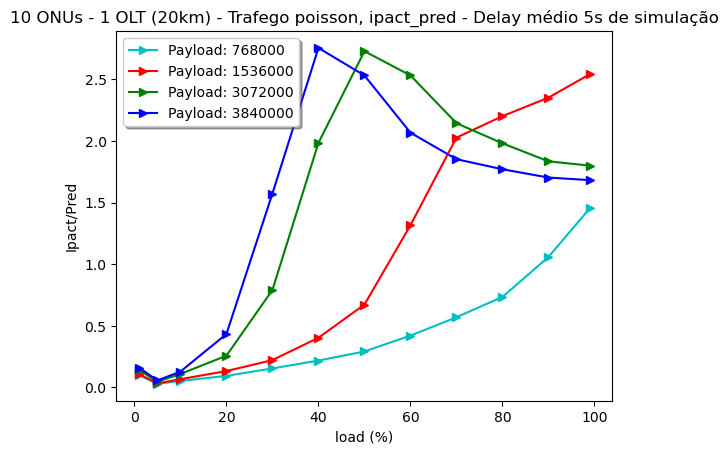

In [32]:
plt.figure()
title = "{} ONUs - {} OLT ({}km) - Trafego {}, {} - Delay médio 5s de simulação".format(NUMBER_OF_ONUs, NUMBER_OF_OLTs, DISTANCE, TRAFFIC, DBA_ALG)
plt.title(title)
plt.xlabel("load (%)")
plt.ylabel("Ipact/Pred")
cmap = plt.get_cmap('gnuplot')
colors = ['c', 'r', 'g', 'b']
#plt.errorbar(loads, ipact_df.iloc[0].values,ipact_df.iloc[1].values,color="k", linestyle='None')
#plt.plot(loads, ipact_df.iloc[0], 'o-', color="k",label="IPACT")


i = 0
for size in PKT_SIZES:
    aux_label = "Payload: {}".format(size)
    array_aux = np.array(visual_df[size])
    print(array_aux)
    #plt.errorbar(loads, array_aux[:,0], array_aux[:,1], color=colors[j], linestyle='None')
    plt.plot(loads, array_aux, '->', color=colors[i], label=aux_label)
    print(array_aux)
    i += 1

#array_aux = np.array(ipact_basic_df)
#aux_label = 'Ipact Básico'
#plt.plot(loads, array_aux[0], '->', color='c', label=aux_label)

#plt.axhline(y=ipact_basic_df[0], color='r', li1nestyle='-', label='Ipact Básico')

plt.legend(loc='best', shadow=True)
plt.show()